In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [5]:
# Load dataset
df = pd.read_csv('WorldEnergy.csv')

# Filter to latest 10 years only
df['year'] = pd.to_numeric(df['year'], errors='coerce')
latest_year = df['year'].max()
df = df[df['year'] >= latest_year - 9]

# List of continents (since they are in 'country' column)
continents = ['Asia', 'Africa', 'Antarctica', 'Australia', 'Europe', 'North America', 'South America']

# Filter only continents
df = df[df['country'].isin(continents)]


print("\nUsing data from year:", latest_year - 9, "to", latest_year)

# Preview dataset
print(df.head())
#statistical info
print(df.info())
print(df.describe())


Using data from year: 2015 to 2024
    country  year iso_code    population  gdp  biofuel_cons_change_pct  \
264  Africa  2015      NaN  1.220073e+09  NaN                   21.518   
265  Africa  2016      NaN  1.251206e+09  NaN                  -21.313   
266  Africa  2017      NaN  1.282900e+09  NaN                   -1.911   
267  Africa  2018      NaN  1.315407e+09  NaN                   56.879   
268  Africa  2019      NaN  1.348003e+09  NaN                   34.246   

     biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
264                    0.148                    0.685                0.836   
265                   -0.178                    0.526                0.658   
266                   -0.013                    0.503                0.646   
267                    0.367                    0.770                1.013   
268                    0.347                    1.009                1.359   

     biofuel_elec_per_capita  ...  solar_share_ele

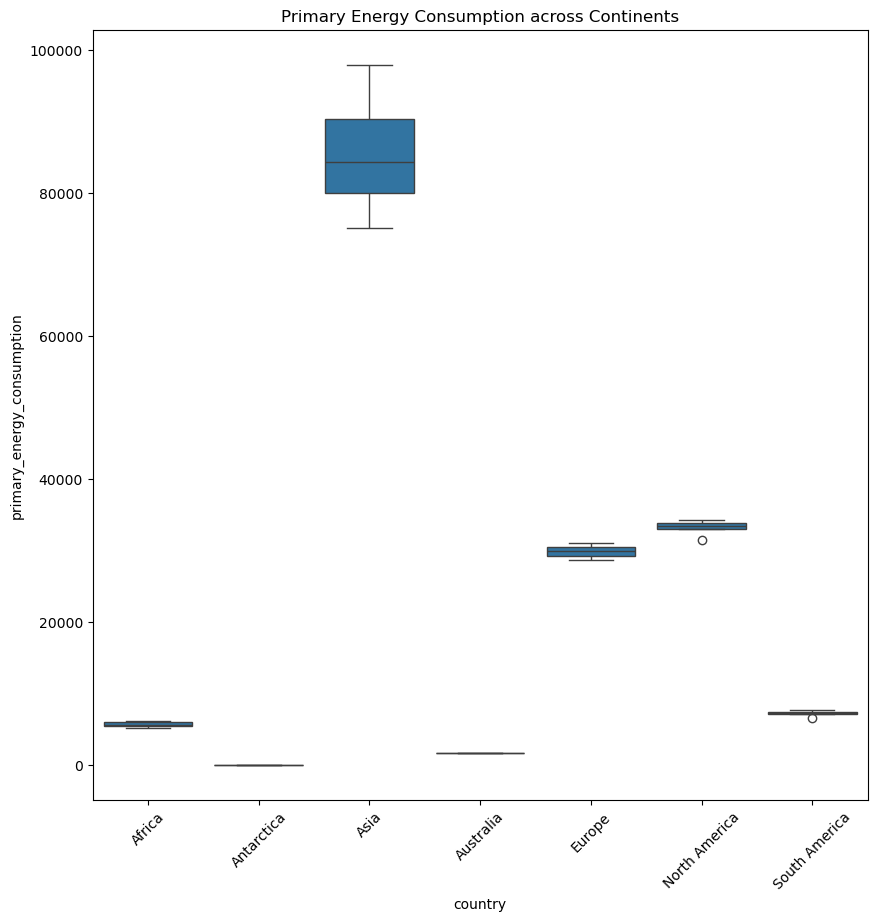

In [43]:
plt.figure(figsize=(10,10))

sns.boxplot(x='country', y='primary_energy_consumption', data=df)

plt.title('Primary Energy Consumption across Continents')
plt.xticks(rotation=45)

plt.show()

In [6]:
# One-Way ANOVA ()
model_1way = ols('primary_energy_consumption ~ C(country)', data=df).fit()
anova_1way = sm.stats.anova_lm(model_1way, typ=2)
print(anova_1way)

# Interpretation
# If p-value < 0.05, primary energy consumption is significantly different across the continents.
# F-statistic = ratio of between-group to within-group variation.

                  sum_sq    df            F        PR(>F)
C(country)  5.517538e+10   6.0  1080.722298  9.612310e-61
Residual    5.275597e+08  62.0          NaN           NaN


In [7]:
#If ANOVA is significant, use Tukey’s test to find which continent pairs differ.

tukey_result = pairwise_tukeyhsd(df['primary_energy_consumption'], df['country'], alpha=0.05)
print(tukey_result)

# The Tukey summary shows which pairs of continents differ significantly (based on mean strength).

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
    group1        group2      meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------------------
       Africa    Antarctica  -5652.8131 0.0015  -9736.9174  -1568.7089   True
       Africa          Asia  79680.6887    0.0  75705.5135  83655.8639   True
       Africa     Australia  -4024.6907 0.0453  -7999.8659    -49.5155   True
       Africa        Europe  24149.2456    0.0  20174.0704  28124.4208   True
       Africa North America  27634.3888    0.0  23659.2136   31609.564   True
       Africa South America    1574.117  0.889  -2401.0582   5549.2922  False
   Antarctica          Asia  85333.5018    0.0  81249.3976  89417.6061   True
   Antarctica     Australia   1628.1224 0.8858  -2455.9818   5712.2267  False
   Antarctica        Europe  29802.0587    0.0  25717.9545   33886.163   True
   Antarctica North America  33287.2019    0.0  29203.0977  3737

In [9]:
df.groupby(['country','year']).size()

country        year
Africa         2015    1
               2016    1
               2017    1
               2018    1
               2019    1
                      ..
South America  2020    1
               2021    1
               2022    1
               2023    1
               2024    1
Length: 69, dtype: int64

In [12]:
# Two-Way ANOVA (country & year)

model_2way = ols('primary_energy_consumption ~ C(country) + C(year)', data=df).fit()
anova_2way = sm.stats.anova_lm(model_2way, typ=2)
print(anova_2way)

# Interpretation
# C(country): main effect of country
# C(year): main effect of time in year


                  sum_sq    df            F        PR(>F)
C(country)  5.498812e+10   6.0  1099.720155  9.390818e-54
C(year)     8.587614e+07   9.0     1.144971  3.489527e-01
Residual    4.416836e+08  53.0          NaN           NaN


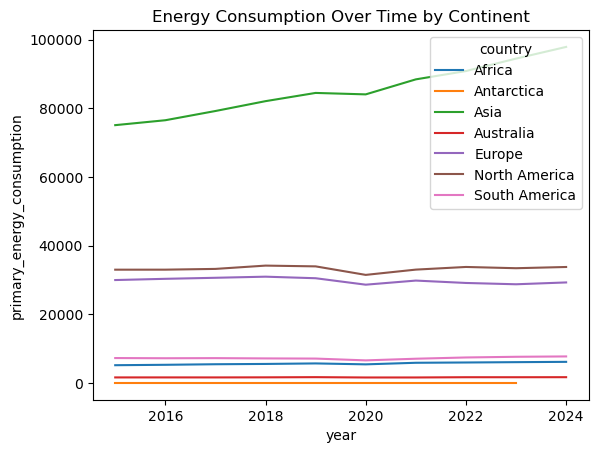

In [14]:
# Changes in Primary Energy Consumption by Continents within 10 Years

sns.lineplot(data=df, x='year', y='primary_energy_consumption', hue='country')
plt.title("Energy Consumption Over Time by Continent")
plt.show()

In [18]:
# Normality Test (Shapiro-Wilk)
# if p > 0.05 → residuals are normally distributed.

residuals = model_2way.resid
shapiro_test = stats.shapiro(residuals)
print("Shapiro-Wilk Test:", shapiro_test)


Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.8297660350936163), pvalue=np.float64(1.8942420057743178e-07))


<Axes: ylabel='Count'>

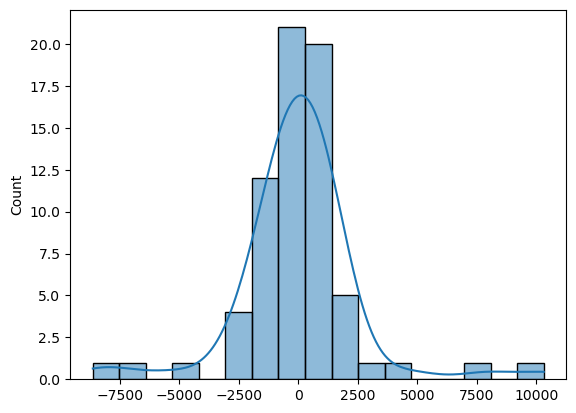

In [17]:
sns.histplot(residuals, kde=True)